In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from matplotlib.colors import LinearSegmentedColormap

from group_sae.utils import load_cluster_map

### Parameters

In [9]:
model_name = "pythia-1b"
max_tokens = 1_000_000
count_dir = "./counts"
K = 2

In [10]:
cluster_map = load_cluster_map("1b")
cluster_ids = cluster_map[str(K)]
cluster_ids

['k2-c0',
 'k2-c0',
 'k2-c0',
 'k2-c0',
 'k2-c0',
 'k2-c0',
 'k2-c0',
 'k2-c0',
 'k2-c0',
 'k2-c1',
 'k2-c1',
 'k2-c1',
 'k2-c1',
 'k2-c1',
 'k2-c1']

### Load count matrix

In [11]:
counter_mat = np.load(f"{count_dir}/counter_mat_{model_name}_K{K}_{max_tokens}.npy")
counter_mat = torch.from_numpy(counter_mat)

In [12]:
# Normnalize the counter matrix by groups counts
plot_mat = torch.zeros_like(counter_mat).float()

for cid in np.unique(cluster_ids):
    mask = np.array(cluster_ids) == cid
    sub_mat = counter_mat[mask].float()
    sub_mat /= sub_mat.sum(dim=0, keepdim=True)

    # Sorting by layer frequency
    weight = (
        torch.arange(sub_mat.shape[0], device=sub_mat.device).float().unsqueeze(1) * sub_mat
    ).sum(0)
    _, idx = torch.sort(weight, descending=False)
    plot_mat[mask] = sub_mat[:, idx]

plot_mat = plot_mat.cpu().numpy()

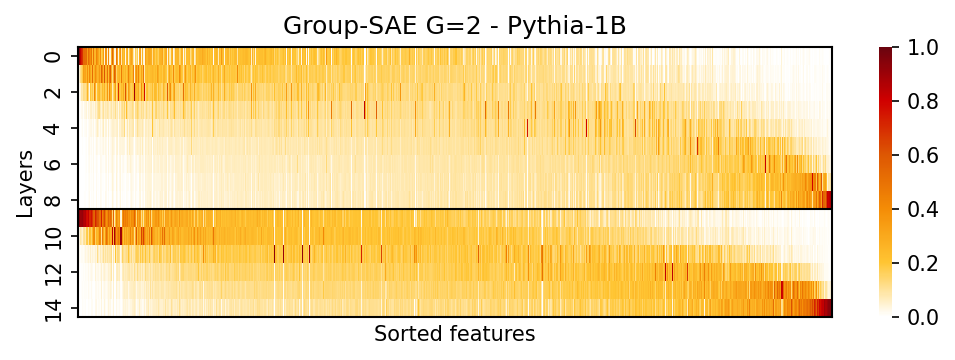

In [13]:
fig, ax = plt.subplots(figsize=(7, 2.5), dpi=150)

palette = ["#FFFFFF", "#FFC533", "#f48c06", "#DD5703", "#d00000", "#6A040F"]
cmap = LinearSegmentedColormap.from_list("paper", palette)

# Create the heatmap
sns.heatmap(plot_mat, cmap=cmap, annot=False, ax=ax)

# Remove x-ticks (as in your original code) but keep y-ticks if you wish
ax.set_xticks([])
ax.set_xlabel("Sorted features")
ax.set_ylabel("Layers")
ax.set_title(f"Group-SAE G={K} - {model_name.title()}")

# 1. Add a border around the heatmap
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color("black")

# 2. Add horizontal lines where cluster_ids change
# Find the row indices where the cluster ID changes
cluster_changes = []
for i in range(1, len(cluster_ids)):
    if cluster_ids[i] != cluster_ids[i - 1]:
        cluster_changes.append(i)

# The number of columns in the heatmap is half of plot_mat.shape[1] (since we used ::2)
n_cols = plot_mat.shape[1]

# Draw horizontal lines
for row in cluster_changes:
    ax.hlines(y=row, xmin=0, xmax=n_cols, color="black", linewidth=1)

plt.tight_layout()
plt.show()

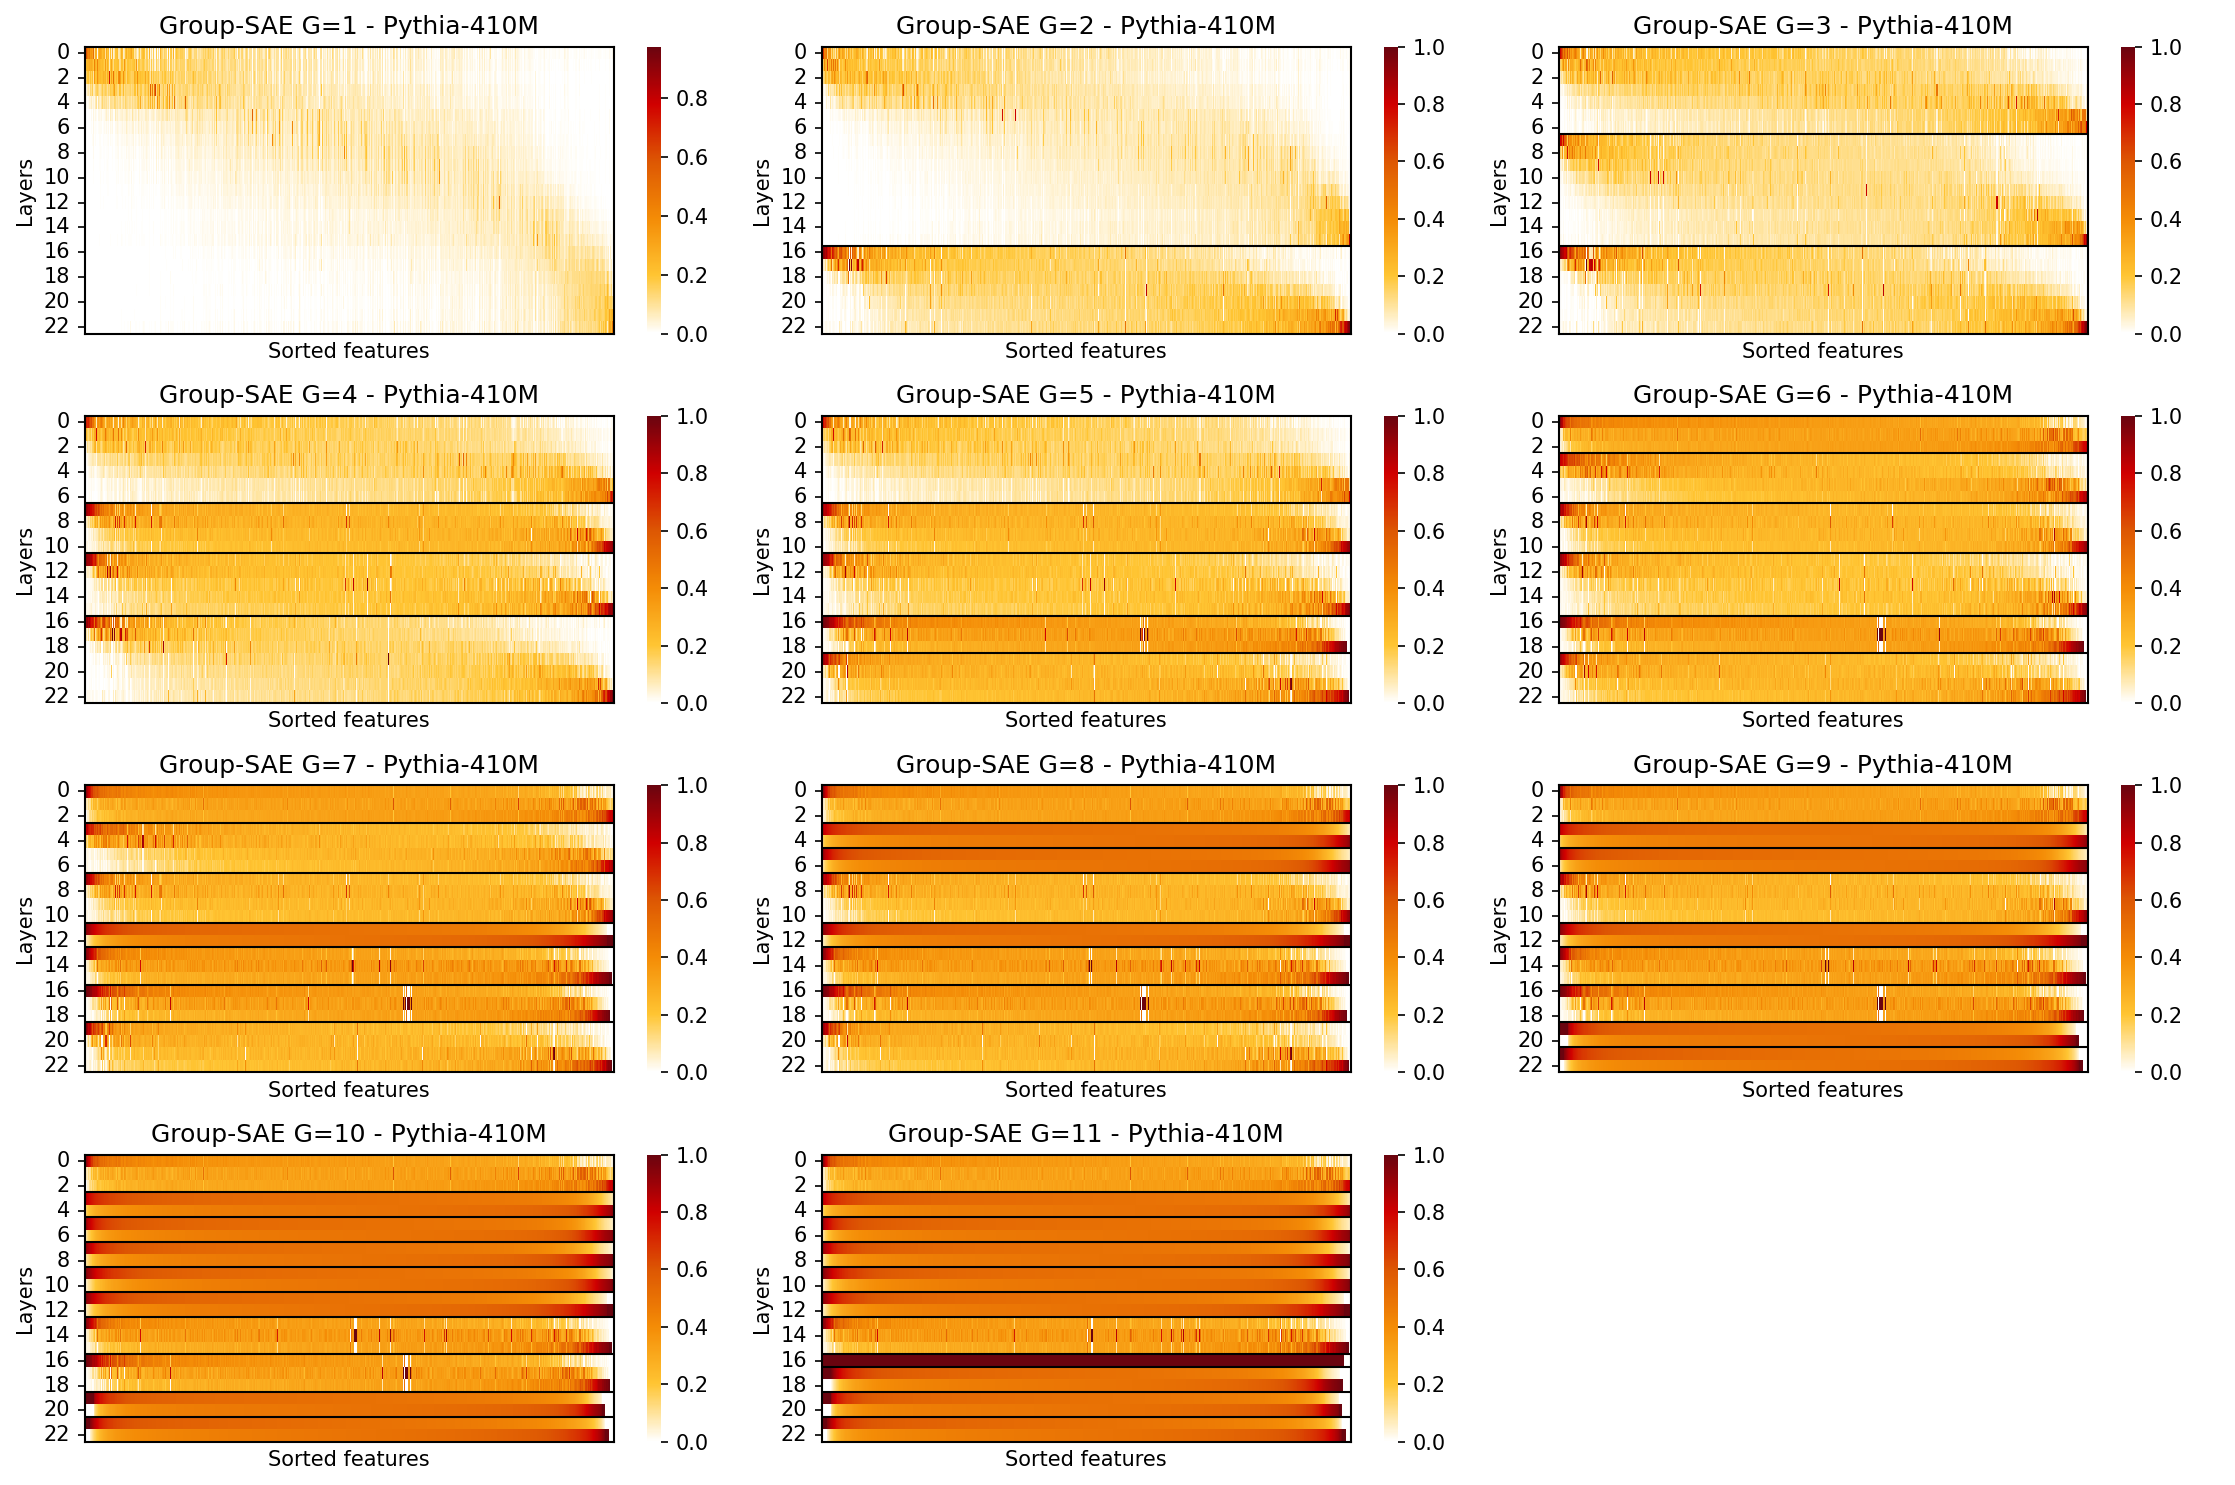

In [3]:
from math import ceil

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from matplotlib.colors import LinearSegmentedColormap

from group_sae.utils import load_cluster_map

# Parameters
model_name = "pythia-410m"
max_tokens = 1_000_000
count_dir = "./counts"

# Load the cluster map and get available K values
cluster_map = load_cluster_map("410m")
Ks = sorted([int(k) for k in cluster_map.keys()])  # e.g., [2, 3, 4, ...]
Ks = Ks[: len(Ks) // 2]

# Define a custom colormap using a palette
palette = ["#FFFFFF", "#FFC533", "#f48c06", "#DD5703", "#d00000", "#6A040F"]
cmap_custom = LinearSegmentedColormap.from_list("paper", palette)

# Setup subplot grid: 3 columns and as many rows as needed
n_K = len(Ks)
n_cols = 3
n_rows = ceil(n_K / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 2.5 * n_rows), dpi=150)
axes = axes.flatten()  # Flatten the axes array for easy iteration

for i, K in enumerate(Ks):
    ax = axes[i]

    # Get cluster IDs for current K
    cluster_ids = cluster_map[str(K)]

    # Load the corresponding counter matrix
    counter_mat = np.load(f"{count_dir}/counter_mat_{model_name}_K{K}_{max_tokens}.npy")
    counter_mat = torch.from_numpy(counter_mat)

    # Normalize the counter matrix by group counts and sort each group by layer frequency
    plot_mat = torch.zeros_like(counter_mat).float()
    unique_ids = np.unique(cluster_ids)
    for cid in unique_ids:
        mask = np.array(cluster_ids) == cid
        sub_mat = counter_mat[mask].float()
        sub_mat /= sub_mat.sum(dim=0, keepdim=True)

        # Sorting by layer frequency
        weight = (
            torch.arange(sub_mat.shape[0], device=sub_mat.device).float().unsqueeze(1) * sub_mat
        ).sum(0)
        _, idx = torch.sort(weight, descending=False)
        plot_mat[mask] = sub_mat[:, idx]

    plot_mat = plot_mat.cpu().numpy()

    # Create the heatmap for the current K
    sns.heatmap(plot_mat, cmap=cmap_custom, annot=False, ax=ax)
    ax.set_xticks([])
    ax.set_xlabel("Sorted features")
    ax.set_ylabel("Layers")
    ax.set_title(f"Group-SAE G={K} - {model_name.title()}")

    # Add a border around the heatmap
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1)
        spine.set_color("black")

    # Add horizontal lines where cluster_ids change
    cluster_changes = [
        j for j in range(1, len(cluster_ids)) if cluster_ids[j] != cluster_ids[j - 1]
    ]
    n_cols_heatmap = plot_mat.shape[1]
    for row in cluster_changes:
        ax.hlines(y=row, xmin=0, xmax=n_cols_heatmap, color="black", linewidth=1)

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()